In [83]:
import os
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
import jax.random as jr
from astropy.io import fits
from hmc_dust.better_hmc import HMCSampler
import jax.scipy.special as jss
import arviz as az
import blackjax
from jax.scipy.stats import t
import scipy
from jax.scipy.special import logsumexp
from jax.scipy.special import gammaln
from jax.scipy.stats import norm

from hmc_dust import DATA, GAIA


from pathlib import Path

data_file = Path('../Output Files/overall_data_Gaia_XP_fitting_actual_data_final_run.npy')
tag = data_file.stem.removeprefix('overall_data_')
# -> 'Gaia_XP_fitting_actual_data_final_run'


INV_GAMMA_MEAN = 4
INV_GAMMA_VAR  = jnp.inf

#inv_gamma_variance_prior_alpha = INV_GAMMA_MEAN**2/INV_GAMMA_VAR + 2
#inv_gamma_variance_prior_beta = INV_GAMMA_MEAN**3/INV_GAMMA_VAR + INV_GAMMA_MEAN
inv_gamma_variance_prior_alpha = 1.5
inv_gamma_variance_prior_beta = 2
student_t_sigma = jnp.sqrt(inv_gamma_variance_prior_beta/inv_gamma_variance_prior_alpha)
student_t_nu = 2*inv_gamma_variance_prior_alpha

overall_data_arr = jnp.asarray(np.load(data_file))
accept_prob_arr = jnp.zeros(overall_data_arr[0].size)


RUN = os.environ.get("SLURM_JOB_ID", "local")


def out(name):
    root, ext = os.path.splitext(name)
    return f"{root}_{RUN}{ext}"


fits_table = Table.read(GAIA / "gc_sightline.fits")


gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs


star_coords = SkyCoord(np.asarray(fits_table["ra"])*u.deg, np.asarray(fits_table["dec"])*u.deg)
fits_table["sep_gc_deg"] = star_coords.separation(gc_builtin).deg




plx_np = fits_table["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = fits_table["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = fits_table["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = fits_table["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = fits_table["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(fits_table.info())


with fits.open(DATA / "mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)


# 1000/x is its own inverse so this fcn is also plx_to_dist
def dist_to_plx(dist):
    return 1000/dist


def get_x_err_basic(plx_err, plx):
    return 1000*(plx**(-2))*plx_err


def logposterior_on_r(r, w, w_err):
    p_w_given_r = -0.5*(w - 1000/r)**2/(w_err**2)
    p_r = distance_logprior(r)
    return p_r + p_w_given_r


def get_x_err_advanced(plx_err, plx):
    x = jnp.linspace(0.1, 100000, 20000)
    log_posterior = logposterior_on_r(x, plx, plx_err)
    y = jnp.exp(log_posterior - jnp.max(log_posterior))
    Z    = jnp.trapezoid(y, x)                    
    mean = jnp.trapezoid(x * y, x) / Z
    var  = jnp.trapezoid((x - mean) ** 2 * y, x) / Z
    return jnp.sqrt(var)


def distance_logprior(r):
    return jnp.where(r > 0, -r/10000 + 2*jnp.log(r), -jnp.inf)








assert mean_along_center.shape == distance_gaps.shape
num_stars = plx.size
distances_psc = dist_to_plx(plx)


linspace = jnp.linspace(0.1, 20000, 500)
x_err_basic = jax.vmap(get_x_err_basic, in_axes=(None, 0))(0.1, 1000/linspace)
x_err_advanced = jax.vmap(get_x_err_advanced, in_axes=(None, 0))(0.1, 1000/linspace)


num_dimensions = 600
num_fourier_dimensions = 3000
left_distance_padding = 40
right_distance_padding = 600
doing_burn_in = True
use_NUTS = False
use_blackjax_hmc = False
window_adapt_square_mass_matrix = False




min_distance = radial_boundaries[0] - left_distance_padding
max_distance = radial_boundaries[radial_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
integrating_dims_padding_left = 20
integrating_dims_padding_right = 300
total_integrating_dims = integrating_dims_padding_left + integrating_dims_padding_right + num_dimensions
integrating_dust_x_linspace = jnp.arange(num_dimensions + integrating_dims_padding_left + integrating_dims_padding_right)*dx + min_distance - integrating_dims_padding_left*dx
# This is the analouge of fixed_points_linspace
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance

fourier_length = dx*(num_fourier_dimensions - 1)
num_fitting_params = 3
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
error_bars_on_data = 0.025


cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)])


x_obs = dist_to_plx(plx)
y_obs = ext




mask = (separation < 0.3) & (plx - plx_err > 1000/1800) & (plx + plx_err < 1000/40)
x_obs = x_obs[mask]
y_obs = y_obs[mask]
plx_obs = plx[mask]
data_ext_err = ext_err[mask]
data_plx_err = plx_err[mask]
x_error = jax.vmap(get_x_err_basic)(plx_err[mask], plx_obs)
num_data = x_obs.size
inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(ext_err[mask]**2))
inv_cov_plx_matrix = jnp.linalg.inv(jnp.diag(plx_err[mask]**2))


initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.6


logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset


normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
fixed_logscale = jnp.log(2*(max_distance - min_distance))
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
num_integration_steps = 20000
initial_step_size = 0.00006
step_size = initial_step_size


def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2

def inv_gamma_logpdf(x, alpha, beta):
    # β^α / Γ(α) * x^(-α-1) * exp(-β/x),  x > 0
    return jnp.where(
        x > 0,
        alpha * jnp.log(beta) - gammaln(alpha) - (alpha + 1.0) * jnp.log(x) - beta / x,
        -jnp.inf,
    )

def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])

def average_chi_2_based_on_extinction(r, extinction, x_field, y_field, inverse_data_cov):
    def single(r_i, y_field_i):
        model_at_stars = jnp.interp(r_i, x_field, y_field_i)
        residual = extinction - model_at_stars
        return residual.T @ inverse_data_cov @ residual
    return jnp.average(jax.vmap(single, in_axes=(0, 0))(r, y_field))/extinction.size


def average_chi_2_based_on_r(r, plx_obs, inv_plx_cov):
    def single(r_i):
        residual = dist_to_plx(r_i) - plx_obs
        return residual.T @ inv_plx_cov @ residual
    return jnp.average(jax.vmap(single, in_axes = (0,))(r))/plx_obs.size

def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)


def response_function(xi, r, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(r, dust_x_linspace, exp_int_field)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:3 + num_fourier_dimensions]
    r = x[3 + num_fourier_dimensions:]
    # hardcoded r back to fixed values
    #r = x_obs_true
    inference_params = (logvar, lognu)
    # There are priors on everything: logvar, lognu, offset, xi, and r
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi - jnp.sum(distance_logprior(r))
    field_res = y_obs - response_function(xi, r, inference_params, offset)
    plx_res = plx_obs - dist_to_plx(r)


    field_t_scores = field_res/ext_err[mask]
    log_data_likelihoods = t.logpdf(field_t_scores, df = student_t_nu, loc = 0.0, scale = student_t_sigma)




    # P(all data given field, params, distance) is now the probability of observing the extinctions (first term) times the probabilty of observing the correct distances (second term)
    negative_log_p_d_given_s = -1*jnp.sum(log_data_likelihoods) + 0.5*plx_res.T @ inv_cov_plx_matrix @ plx_res
    return negative_log_p_s + negative_log_p_d_given_s


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]



<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None
Filename: /home/dtfrake/hmc-dust/Data_And_Samplers/mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST


In [84]:
logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]  
overall_star_location_arr = overall_data_arr[:, 3 + num_fourier_dimensions:]

mean_star_location_arr = overall_star_location_arr.mean(axis=0)
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)


overall_extinction_arr_raw_before_offsets = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_extinction_arr, inference_params
)
overall_extinction_arr_raw = overall_extinction_arr_raw_before_offsets + offsets[:, None]
overall_extinction_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_extinction_arr_raw
)
overall_extinction_arr_raw = overall_extinction_arr_raw[:, 0:num_dimensions]
overall_extinction_arr_exp = overall_extinction_arr_exp[:, 0:num_dimensions]



scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)

In [85]:
print(overall_star_location_arr.shape)
print(dust_x_linspace.shape)
print(overall_extinction_arr_exp.shape)

(900, 1657)
(600,)
(900, 600)


Text(0.5, 1.0, 'Student t CDF with df 3.0')

/home/dtfrake/hmc-dust/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/dtfrake/hmc-dust/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


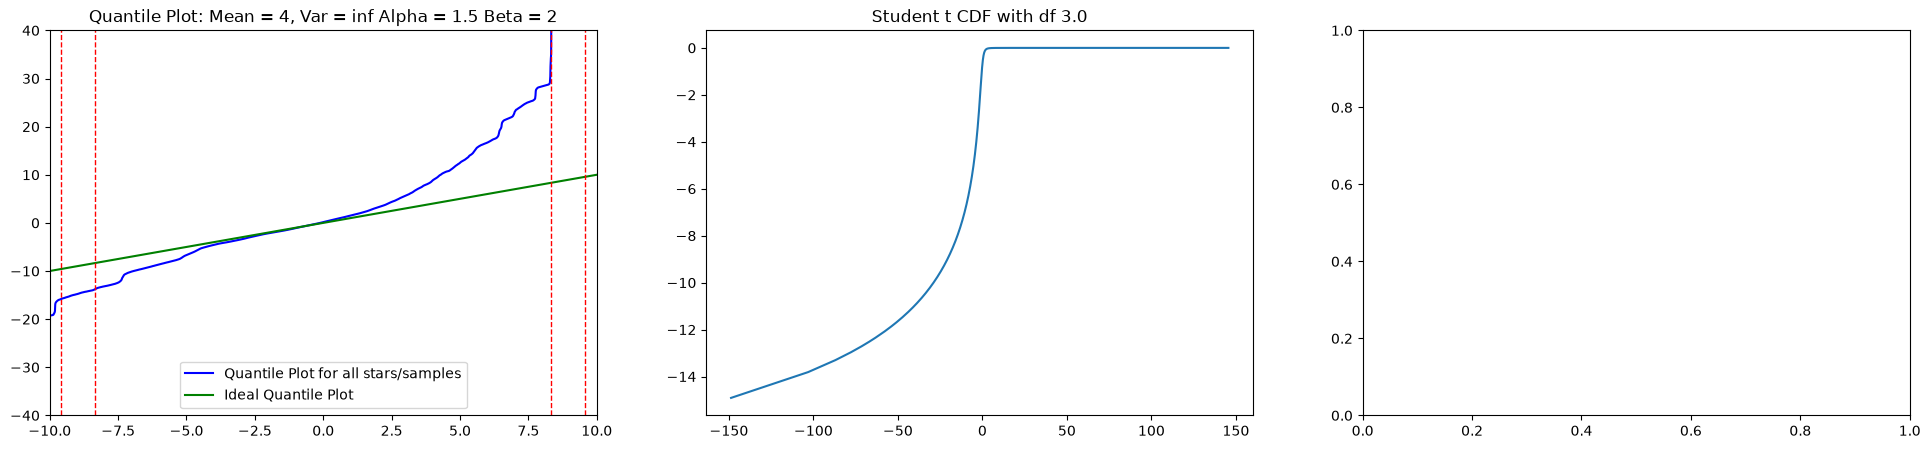

In [86]:
mean_field_at_star_samples_arr = jax.vmap(jnp.interp, in_axes = (0, None, 0))(overall_star_location_arr, dust_x_linspace, overall_extinction_arr_exp)
star_extinction_residuals_samples_arr = y_obs - mean_field_at_star_samples_arr
t_scores = star_extinction_residuals_samples_arr/(data_ext_err*student_t_sigma)   # (200, 1657)
t_scores = jnp.sort(t_scores.ravel())   # (200*1657,) = (331400,) ascending
fractional_positions = (jnp.arange(1, t_scores.size + 1) - 0.5)/t_scores.size
theoretical_t_score = scipy.stats.t.ppf(fractional_positions, df = student_t_nu)
fig, axes = plt.subplots(1, 3, figsize = (24, 5))
axes[0].plot(theoretical_t_score, t_scores, color = "blue", label = "Quantile Plot for all stars/samples")
axes[0].plot(theoretical_t_score, theoretical_t_score, color = "Green", label = "Ideal Quantile Plot")
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-40, 40)
X = y_obs.size   
for i in range(1, 4):
    tail_lo, tail_hi = scipy.stats.t.ppf([i/X, 1 - i/X], df=student_t_nu)
    axes[0].axvline(tail_lo, color="red", linestyle="--", linewidth=1)
    axes[0].axvline(tail_hi, color="red", linestyle="--", linewidth=1)
axes[0].set_title(f"Quantile Plot: Mean = {INV_GAMMA_MEAN}, Var = {INV_GAMMA_VAR} Alpha = {inv_gamma_variance_prior_alpha} Beta = {inv_gamma_variance_prior_beta}")
axes[0].legend()
axes[1].plot(theoretical_t_score, scipy.stats.t.logcdf(theoretical_t_score, df = student_t_nu))
axes[1].set_title(f"Student t CDF with df {student_t_nu}")
